In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from PIL import Image
import os
import time
import copy

DATA_DIR = './dataset'
IMDB_CSV = 'imdb_top_1000.csv'
CHECKPOINT_FILE = 'efficientnet2_checkpoint.pth.tar'

BATCH_SIZE = 8
LEARNING_RATE = 0.001
NUM_EPOCHS = 15
NUM_CLASSES = 7 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Kullanılan Cihaz: {device}")

✅ Kullanılan Cihaz: cuda


In [ ]:

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

dataloaders = {}
dataset_sizes = {}
class_names = []

try:
    image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                      for x in ['train', 'test']}
    
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
                   for x in ['train', 'test']}
    
    dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
    class_names = image_datasets['train'].classes
    
    print(f"✅ Veri seti başarıyla yüklendi.")
    print(f"📂 Sınıflar: {class_names}")
    print(f"📊 Eğitim Verisi: {dataset_sizes['train']} | Test Verisi: {dataset_sizes['test']}")

except Exception as e:
    print(f"❌ HATA: Veri seti yüklenemedi. Yol: {DATA_DIR}")
    print(f"Detay: {e}")
    class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

✅ Veri seti başarıyla yüklendi.
📂 Sınıflar: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
📊 Eğitim Verisi: 28709 | Test Verisi: 7178


In [ ]:

def build_efficientnet_b0_model(num_classes):
    print("🛠️ EfficientNet-B0 modeli hazırlanıyor...")
    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)
    
    final_layer_idx = 1
    in_features = model.classifier[final_layer_idx].in_features
    model.classifier[final_layer_idx] = nn.Linear(in_features, num_classes)
    
    return model

def train_model(model, criterion, optimizer, start_epoch=0, num_epochs=10, best_acc=0.0):
    since = time.time()
    
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(start_epoch, num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['test_loss'].append(epoch_loss)
                history['test_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'test':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                
                torch.save({
                    'epoch': epoch + 1,
                    'state_dict': model.state_dict(),
                    'best_acc': best_acc,
                    'optimizer': optimizer.state_dict(),
                    'history': history
                }, CHECKPOINT_FILE)

    time_elapsed = time.time() - since
    print(f'\n🏁 Eğitim tamamlandı: {time_elapsed // 60:.0f}dk {time_elapsed % 60:.0f}sn')
    print(f'🏆 En iyi Test Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
def evaluate_and_plot(model, loader, history=None):
    """
    1. Loss/Accuracy Grafiklerini çizer (Eğer history varsa).
    2. Confusion Matrix çizer.
    3. ROC Eğrisi çizer.
    """
    
    if history:
        plt.figure(figsize=(14, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(history['train_acc'], label='Train Acc')
        plt.plot(history['test_acc'], label='Test Acc')
        plt.title('Doğruluk (Accuracy) Değişimi')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        plt.plot(history['train_loss'], label='Train Loss')
        plt.plot(history['test_loss'], label='Test Loss')
        plt.title('Hata (Loss) Değişimi')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("ℹ️ Geçmiş (history) verisi bulunamadı, Loss grafikleri çizilmiyor.")

    model.eval()
    y_true = []
    y_pred = []
    y_probs = []
    
    print("\n🔍 Test verileri üzerinde tahmin yapılıyor...")
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Karmaşıklık Matrisi)')
    plt.ylabel('Gerçek')
    plt.xlabel('Tahmin')
    plt.show()

    plt.figure(figsize=(10, 8))
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Eğrisi')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

In [7]:
class MovieRecommender:
    def __init__(self, csv_path):
        self.data_ready = False
        if os.path.exists(csv_path):
            self.df = pd.read_csv(csv_path)
            self.df.columns = [c.strip() for c in self.df.columns]
            self.data_ready = True
        else:
            print(f"⚠️ UYARI: {csv_path} bulunamadı. Öneri sistemi çalışmayacak.")

        self.emotion_genre_map = {
            'Happy': 'Musical|Animation|Comedy',
            'Sad': 'Drama|Romance|Biography',
            'Angry': 'Action|Crime|War',
            'Fear': 'Horror|Thriller|Mystery',
            'Surprise': 'Sci-Fi|Fantasy|Adventure',
            'Disgust': 'Documentary|History',
            'Neutral': 'Drama|Comedy|Adventure'
        }

    def recommend(self, emotion):
        if not self.data_ready: return None
        
        target_genres = self.emotion_genre_map.get(emotion, 'Drama')
        filtered = self.df[self.df['Genre'].str.contains(target_genres, case=False, na=False)]
        
        rating_col = 'IMDB_Rating' if 'IMDB_Rating' in self.df.columns else 'Star_Rating'
        
        if not filtered.empty:
            top_movie = filtered.sort_values(by=rating_col, ascending=False).iloc[0]
            return {
                'Title': top_movie['Series_Title'],
                'Rating': top_movie[rating_col],
                'Genre': top_movie['Genre'],
                'Overview': top_movie.get('Overview', 'No overview')
            }
        return None

🛠️ EfficientNet-B0 modeli hazırlanıyor...
ℹ️ Kayıt dosyası bulunamadı. Sıfırdan başlanacak.
🚀 Eğitim Başlıyor...

Epoch 1/15
----------
train Loss: 1.3206 Acc: 0.4960
test Loss: 1.1660 Acc: 0.5651

Epoch 2/15
----------
train Loss: 1.1373 Acc: 0.5708
test Loss: 1.0835 Acc: 0.5885

Epoch 3/15
----------
train Loss: 1.0654 Acc: 0.6003
test Loss: 1.0258 Acc: 0.6172

Epoch 4/15
----------
train Loss: 1.0173 Acc: 0.6191
test Loss: 0.9948 Acc: 0.6181

Epoch 5/15
----------
train Loss: 0.9723 Acc: 0.6344
test Loss: 0.9840 Acc: 0.6357

Epoch 6/15
----------
train Loss: 0.9360 Acc: 0.6481
test Loss: 0.9855 Acc: 0.6364

Epoch 7/15
----------
train Loss: 0.9077 Acc: 0.6601
test Loss: 0.9410 Acc: 0.6523

Epoch 8/15
----------
train Loss: 0.8787 Acc: 0.6723
test Loss: 0.9442 Acc: 0.6512

Epoch 9/15
----------
train Loss: 0.8508 Acc: 0.6814
test Loss: 0.9401 Acc: 0.6619

Epoch 10/15
----------
train Loss: 0.8287 Acc: 0.6901
test Loss: 0.9114 Acc: 0.6695

Epoch 11/15
----------
train Loss: 0.7985 Acc

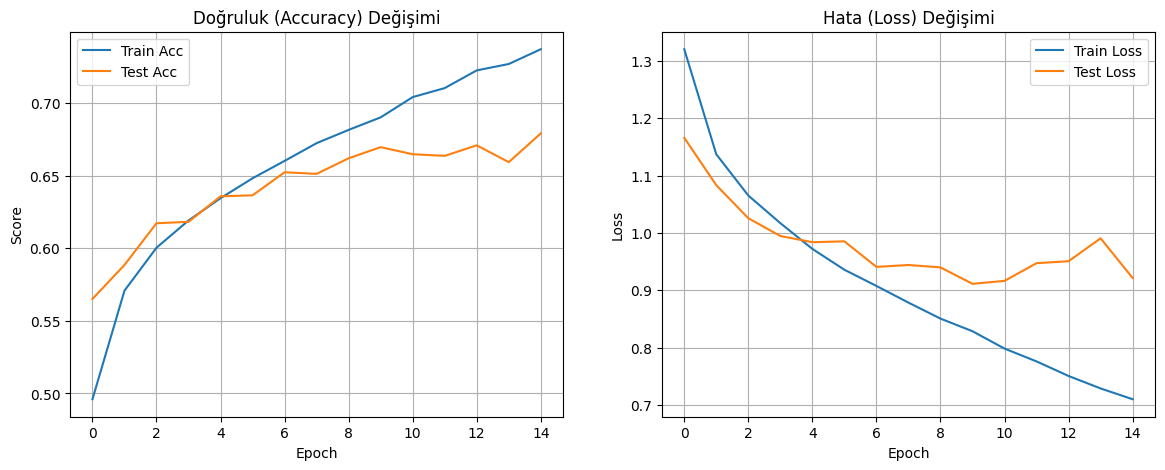


🔍 Test verileri üzerinde tahmin yapılıyor...


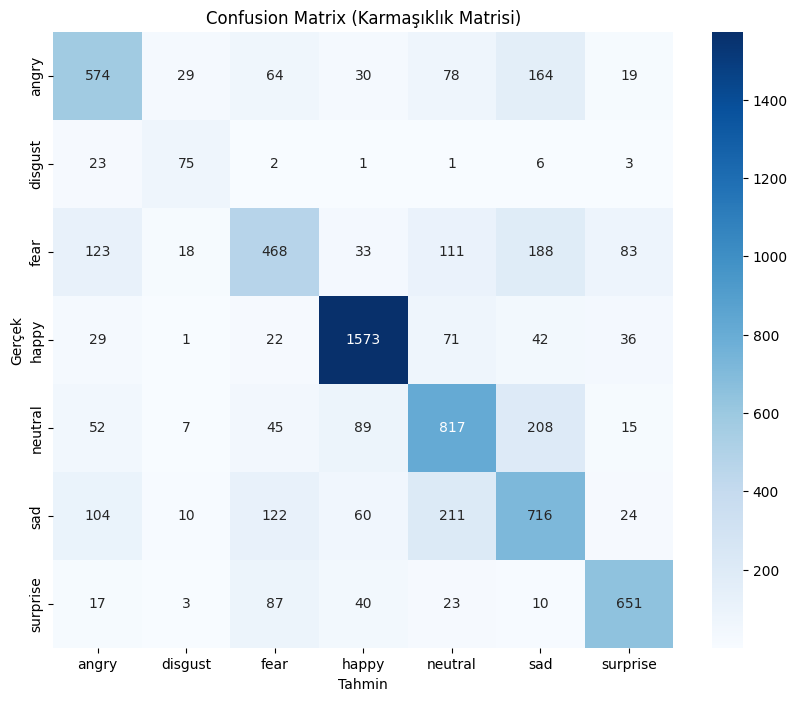

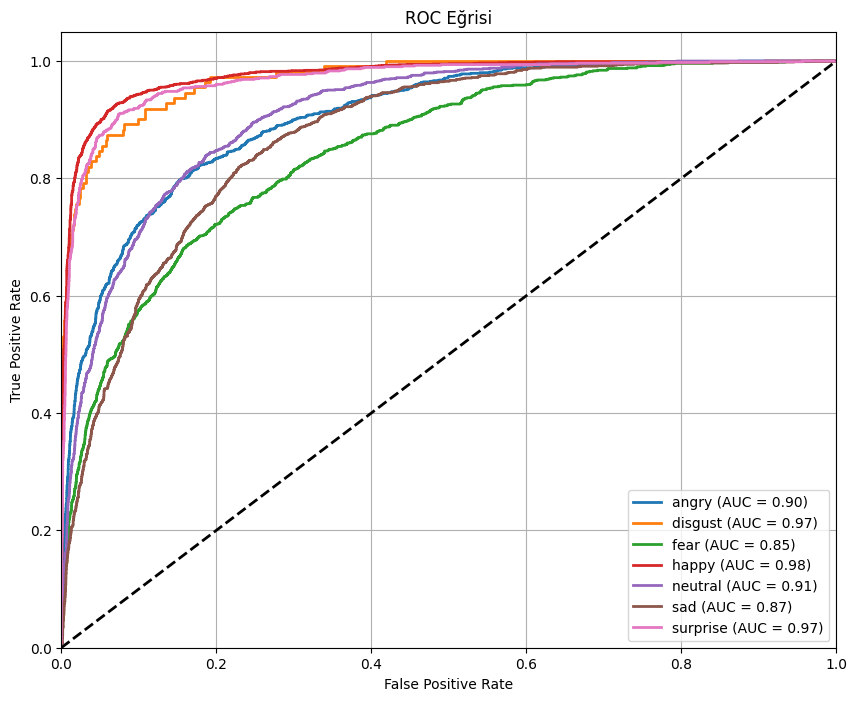


🎬 --- DEMO: Film Önerisi ---
📸 Test Resmi: ./dataset/test/angry/PrivateTest_10131363.jpg
🧠 Tahmin Edilen Duygu: angry
🍿 Önerilen Film: The Shawshank Redemption (9.3/10)
📝 Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts ...


In [ ]:
TRAIN_MODE = True  

model = build_efficientnet_b0_model(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

start_epoch = 0
best_acc = 0.0
history = None

if os.path.exists(CHECKPOINT_FILE):
    print(f"📂 Kayıt dosyası bulundu: {CHECKPOINT_FILE}")
    checkpoint = torch.load(CHECKPOINT_FILE, map_location=device)
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    start_epoch = checkpoint['epoch']
    best_acc = checkpoint['best_acc']
    history = checkpoint.get('history', None)
    print(f"   -> {start_epoch}. epoch'tan devam edilebilir. Best Acc: {best_acc:.4f}")
else:
    print("ℹ️ Kayıt dosyası bulunamadı. Sıfırdan başlanacak.")

if TRAIN_MODE:
    if 'dataloaders' in globals() and 'train' in dataloaders:
        print("🚀 Eğitim Başlıyor...")
        model, history = train_model(model, criterion, optimizer, 
                                     start_epoch=start_epoch, 
                                     num_epochs=NUM_EPOCHS, 
                                     best_acc=best_acc)
        evaluate_and_plot(model, dataloaders['test'], history)
    else:
        print("❌ HATA: Dataloader yüklü değil, eğitim yapılamaz.")

else:
    print("📊 Değerlendirme Modu Başlatılıyor...")
    if 'dataloaders' in globals() and 'test' in dataloaders:
        evaluate_and_plot(model, dataloaders['test'], history)
    else:
        print("❌ HATA: Test verisi (dataloaders['test']) bulunamadı.")
try:
    print("\n🎬 --- DEMO: Film Önerisi ---")
    recommender = MovieRecommender(IMDB_CSV)
    
    test_dir = os.path.join(DATA_DIR, 'test') 
    if os.path.exists(test_dir):
        first_class = os.listdir(test_dir)[0]
        first_img = os.listdir(os.path.join(test_dir, first_class))[0]
        test_img_path = os.path.join(test_dir, first_class, first_img)
        
        img_pil = Image.open(test_img_path).convert('RGB')
        preprocess = data_transforms['test']
        input_tensor = preprocess(img_pil).unsqueeze(0).to(device)
        
        model.eval()
        with torch.no_grad():
            output = model(input_tensor)
            _, pred = torch.max(output, 1)
            
        emotion = class_names[pred.item()]
        print(f"📸 Test Resmi: {test_img_path}")
        print(f"🧠 Tahmin Edilen Duygu: {emotion}")
        
        movie = recommender.recommend(emotion)
        if movie:
            print(f"🍿 Önerilen Film: {movie['Title']} ({movie['Rating']}/10)")
            print(f"📝 {movie['Overview'][:100]}...")
    else:
        print("Demo için uygun test klasörü bulunamadı.")
        
except Exception as e:
    print(f"Demo sırasında hata: {e}")